In [10]:
from numba import cuda, float32
import threading

import math
import numpy as np
import matplotlib.pyplot as plt
from time import time

SHARED_SIZE = 256
KSIZE = 7
RADIUS = KSIZE // 2

In [32]:
@cuda.jit
def grayscale_gpu(src, dst):
  tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
  g = np.uint8((src[tidx, 0] + src[tidx, 1] + src[tidx, 2]) / 3)
  dst[tidx, 0] = dst[tidx, 1] = dst[tidx, 2] = g


@cuda.jit
def min_gpu_1d(src, dst, sharedSize):
  cache = cuda.shared.array((SHARED_SIZE, ), np.int32)
  n = src.shape[0]
  localtid = cuda.threadIdx.x
  tid = localtid + cuda.blockIdx.x * cuda.blockDim.x
  if tid < n:
    cache[localtid] = src[tid, 0]
  else:
    cache[localtid] = 255
  cuda.syncthreads()
  s = cuda.blockDim.x // 2
  while s > 0:
    if localtid < s:
      cache[localtid] = min(cache[localtid], cache[localtid + s])
    cuda.syncthreads()
    s //= 2
  if localtid == 0:
    dst[cuda.blockIdx.x] = cache[0]


@cuda.jit
def max_gpu_1d(src, dst, sharedSize):
  cache = cuda.shared.array((SHARED_SIZE, ), np.int32)
  n = src.shape[0]
  localtid = cuda.threadIdx.x
  tid = localtid + cuda.blockIdx.x * cuda.blockDim.x
  if tid < n:
    cache[localtid] = src[tid, 0]
  else:
    cache[localtid] = 0
  cuda.syncthreads()
  s = cuda.blockDim.x // 2
  while s > 0:
    if localtid < s:
      cache[localtid] = max(cache[localtid], cache[localtid + s])
    cuda.syncthreads()
    s //= 2
  if localtid == 0:
    dst[cuda.blockIdx.x] = cache[0]


def reduce_gpu(src, kernel, sharedSize, host_op):
  pixelCount = src.shape[0]
  gridSize = math.ceil(pixelCount / sharedSize)
  output = cuda.device_array((gridSize, ), np.int32)
  kernel[gridSize, sharedSize](src, output, sharedSize)
  partial = output.copy_to_host()
  return int(host_op(partial))



@cuda.jit
def rgb2graystretch_gpu_2d(grayscale, graystretch, gray_min, gray_max):
  tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
  tidy = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y

  h, w, _ = grayscale.shape
  if tidx < w and tidy < h:
    v = np.uint8((grayscale[tidy, tidx, 0] - gray_min) / (gray_max - gray_min) * 255)
    graystretch[tidy, tidx, 0] = v
    graystretch[tidy, tidx, 1] = v
    graystretch[tidy, tidx, 2] = v

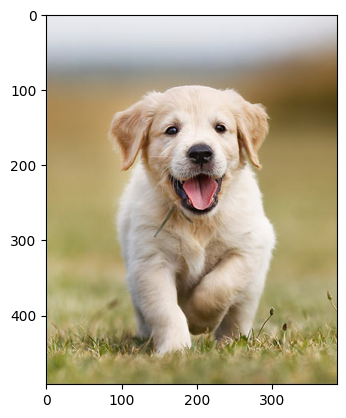

In [33]:
img_src = "/content/drive/MyDrive/DATA/HPC/image.jpg"
img=plt.imread(img_src, format=None)
plt.imshow(img)
plt.show()

In [34]:
pixel_count = img.shape[0] * img.shape[1]
img_flat = img.reshape(pixel_count, 3)

img_flat

array([[254, 255, 255],
       [237, 238, 240],
       [231, 232, 234],
       ...,
       [134, 130,  85],
       [136, 132,  87],
       [138, 134,  89]], dtype=uint8)

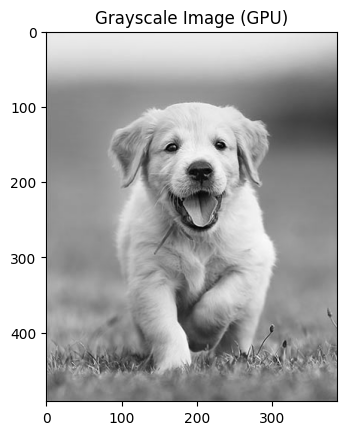

In [35]:
img_flat = np.array(img_flat, copy=True)
gray_flat = np.zeros_like(img_flat)

threads_per_block = 64
blocks_per_grid = (pixel_count + threads_per_block - 1) // threads_per_block

d_img = cuda.to_device(img_flat)
d_gray = cuda.to_device(gray_flat)

start_time_gpu = time()

grayscale_gpu[blocks_per_grid, threads_per_block](d_img, d_gray)

cuda.synchronize()

end_time_gpu = time()

gray_flat = d_gray.copy_to_host()
gray_image_gpu = gray_flat.reshape(img.shape)

plt.imshow(gray_image_gpu)
plt.title('Grayscale Image (GPU)')
plt.show()

In [31]:
start = time()
min_gpu = reduce_gpu(d_gray, min_gpu_1d, SHARED_SIZE, np.min)
max_gpu = reduce_gpu(d_gray, max_gpu_1d, SHARED_SIZE, np.max)
cuda.synchronize()
end = time()

print(f"GPU: min = {min_gpu}")
print(f"max = {max_gpu}")
print(f"time = {end - start:.6f}s")

GPU: min = 0
max = 254
time = 0.005043s


min = 0, max = 254, time = 0.311950s


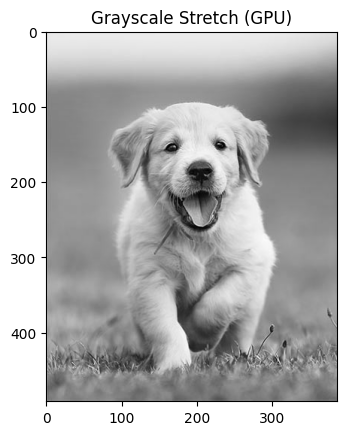

In [37]:
h, w, _ = img.shape
d_gray_3d = d_gray.reshape(img.shape)
d_stretch = cuda.to_device(np.zeros(img.shape, dtype=np.uint8))

threads = (16, 16)
blocks = (math.ceil(w / threads[0]), math.ceil(h / threads[1]))

start_time = time()
rgb2graystretch_gpu_2d[blocks, threads](d_gray_3d, d_stretch, min_gpu, max_gpu)
cuda.synchronize()
end_time = time()

stretch_img = d_stretch.copy_to_host()
print(f"min = {min_gpu}, max = {max_gpu}, time = {end_time - start_time:.6f}s")

plt.imshow(stretch_img)
plt.title('Grayscale Stretch (GPU)')
plt.show()